# Rates and curve models — `fixed_income`

This notebook demonstrates **Treasury par data**, **Nelson–Siegel** and **Nelson–Siegel–Svensson** fits, **Treasury spot bootstrap**, **SOFR OIS discounting**, **forwards**, and **Hull–White** calibration to CME SOFR futures.

**Install:**
```bash
python3 -m pip install -e '.[data,viz]'
```

**Optional:** `FRED_API_KEY` in `.env`, network for Treasury/NY Fed, and CME CSVs under `data/raw/` (see [data_access.md](../docs/data_access.md)).

Yields are in **decimal** in code (e.g. `0.045`) and shown in **percent** on charts.

In [1]:
from dataclasses import replace
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from fixed_income.rates.hull_white import accrual_window_years

from fixed_income import (
    NelsonSiegel,
    NelsonSiegelSvensson,
    HullWhite,
    bootstrap_ois_from_sofr,
    bootstrap_spot_curve,
    forward_rate_from_discount,
)
from fixed_income.data import (
    CurvePoint,
    ParCurve,
    RateObservation,
    RateSeries,
    FuturesSettleCurve,
    TreasuryParCurveSource,
    NyFedSofrSource,
    CmeSofrSettleBundleSource,
)
from fixed_income.rates import USTreasurySpotCurve

AS_OF = date(2026, 5, 22)
PILLARS = [0.25, 0.5, 1.0, 2.0, 5.0]

sns.set_theme(style="whitegrid", context="talk", palette="deep")


def pct(x, _pos=None):
    return f"{100.0 * float(x):.2f}%"


pct_formatter = FuncFormatter(pct)


def curve_to_df(curve: ParCurve) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "maturity_years": [p.maturity_years for p in curve.points],
            "par_yield": [p.par_yield for p in curve.points],
        }
    )
    df["par_yield_pct"] = 100.0 * df["par_yield"]
    return df


def plot_par_curve(df: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=df, x="maturity_years", y="par_yield", ax=ax, linewidth=2, label="Par")
    sns.scatterplot(data=df, x="maturity_years", y="par_yield", ax=ax, s=70, zorder=3)
    ax.yaxis.set_major_formatter(pct_formatter)
    ax.set_title(title)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_yield_fits(curve: ParCurve, fits: list, labels: list, title: str) -> None:
    t = np.asarray([p.maturity_years for p in curve.points], dtype=float)
    r = np.asarray([p.par_yield for p in curve.points], dtype=float)
    grid = np.linspace(float(t.min()), float(t.max()), 200)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(t, r, s=70, label="Observed par", zorder=4)
    for model, label in zip(fits, labels):
        ax.plot(grid, model.f(grid), linewidth=2, linestyle="--", label=label)
    ax.yaxis.set_major_formatter(pct_formatter)
    ax.set_title(title)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield")
    ax.legend()
    plt.tight_layout()
    plt.show()


def par_curve_for_bootstrap(curve: ParCurve, frequency: int = 2) -> ParCurve:
    """Longest contiguous semiannual tenor chain from the shortest maturity (bootstrap-safe)."""
    by_period: dict[int, CurvePoint] = {}
    for p in curve.points:
        periods = int(round(p.maturity_years * frequency))
        if periods >= 1 and np.isclose(p.maturity_years * frequency, periods, atol=1e-9):
            by_period[periods] = p

    max_period = 0
    for k in range(1, max(by_period, default=0) + 1):
        if k in by_period:
            max_period = k
        else:
            break

    if max_period < 2:
        raise ValueError("Need at least two contiguous semiannual par tenors for bootstrap")

    kept = [by_period[k] for k in range(1, max_period + 1)]
    return ParCurve(as_of=curve.as_of, points=tuple(kept))


def sr3_curve_for_calibration(
    curve: FuturesSettleCurve, as_of: date, min_volume: int = 1
) -> FuturesSettleCurve:
    """SR3 contracts with accrual end after valuation (compatible with OIS forwards)."""
    kept = []
    for s in curve.settles:
        if s.volume is not None and s.volume < min_volume:
            continue
        t0, t1 = accrual_window_years(s.contract_month, as_of, s.product)
        if t1 > max(t0, 0.0):
            kept.append(s)
    return replace(curve, settles=tuple(kept))

## 1. Treasury par curve

Loaded Treasury par from Treasury.gov (2026-05-22)


,maturity_years,par_yield,par_yield_pct
0,0.083333,0.0372,3.72
1,0.166667,0.0369,3.69
2,0.250000,0.0368,3.68
3,0.333333,0.0378,3.78
4,0.500000,0.0379,3.79
5,1.000000,0.0386,3.86
6,2.000000,0.0413,4.13
7,3.000000,0.0418,4.18
8,5.000000,0.0427,4.27
9,7.000000,0.0441,4.41


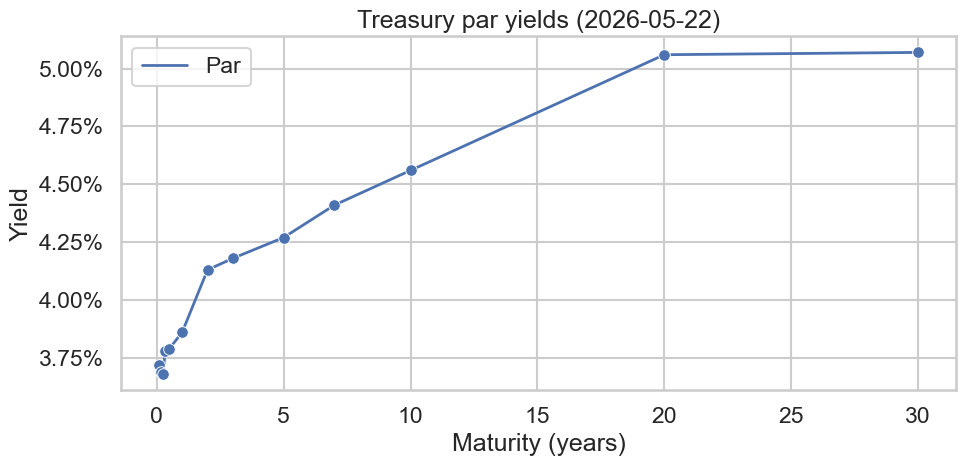

In [2]:
try:
    par_curve = TreasuryParCurveSource().fetch(as_of=AS_OF)
    print(f"Loaded Treasury par from Treasury.gov ({par_curve.as_of})")
except Exception as exc:
    print(f"Live Treasury fetch failed: {exc}")
    print("Using synthetic par curve for offline demo.")
    par_curve = ParCurve(
        as_of=AS_OF,
        points=tuple(
            CurvePoint(0.5 * k, 0.044 + 0.0012 * k)
            for k in range(1, 21)
        ),
    )

df_par = curve_to_df(par_curve)
display(df_par)
plot_par_curve(df_par, title=f"Treasury par yields ({par_curve.as_of})")

## 2. Nelson–Siegel fit

NS: beta0..2 = [ 5.40039193e-02 -1.69051666e-02  2.73328104e-07], tau = 5.288


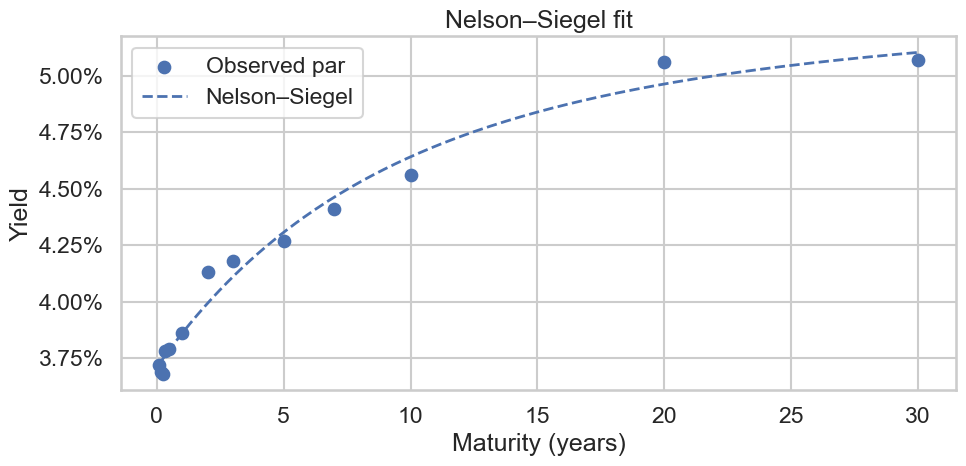

In [3]:
t = np.asarray([p.maturity_years for p in par_curve.points], dtype=float)
r = np.asarray([p.par_yield for p in par_curve.points], dtype=float)

ns = NelsonSiegel(t=t, r=r)
ns.fit(tau0=1.0)
print(f"NS: beta0..2 = {ns.betas}, tau = {ns.tau:.3f}")

plot_yield_fits(par_curve, [ns], ["Nelson–Siegel"], title="Nelson–Siegel fit")

## 3. Nelson–Siegel–Svensson fit

NSS: beta0..3 = [ 0.05447142 -0.01812717  1.76883682 -1.78148296], tau1 = 2.216, tau2 = 2.231


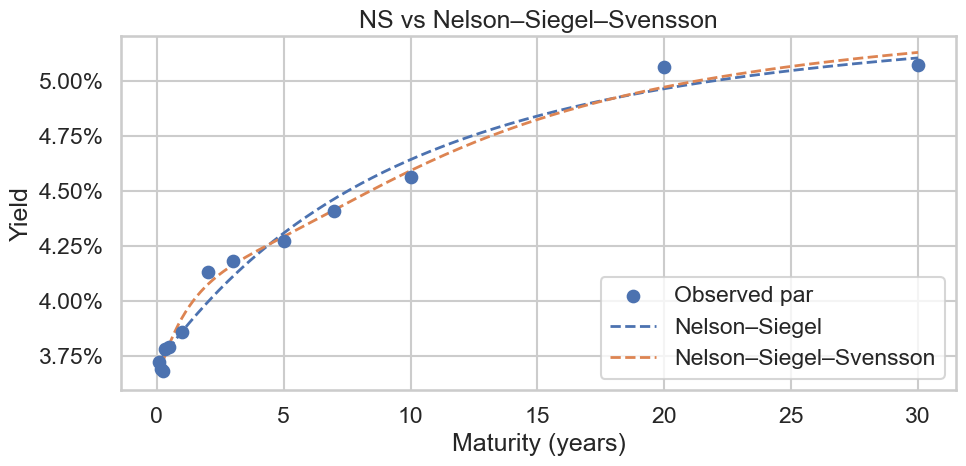

,model,in_sample_sse
0,Nelson–Siegel,0.000005
1,Nelson–Siegel–Svensson,0.000003


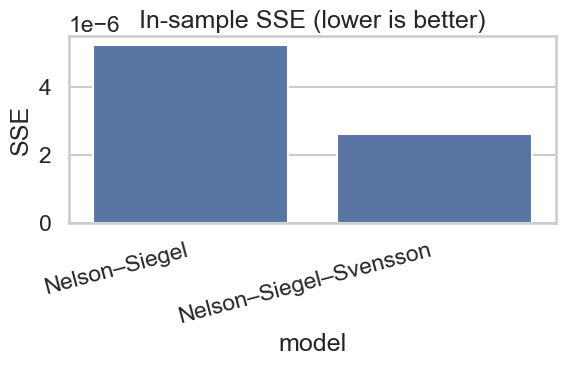

In [4]:
nss = NelsonSiegelSvensson(t=t, r=r)
nss.fit(tau1_0=1.0, tau2_0=3.0)
print(f"NSS: beta0..3 = {nss.betas}, tau1 = {nss.tau1:.3f}, tau2 = {nss.tau2:.3f}")

plot_yield_fits(
    par_curve,
    [ns, nss],
    ["Nelson–Siegel", "Nelson–Siegel–Svensson"],
    title="NS vs Nelson–Siegel–Svensson",
)

sse_ns = float(np.sum((ns.f(t) - r) ** 2))
sse_nss = float(np.sum((nss.f(t) - r) ** 2))
df_sse = pd.DataFrame({"model": ["Nelson–Siegel", "Nelson–Siegel–Svensson"], "in_sample_sse": [sse_ns, sse_nss]})
display(df_sse)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df_sse, x="model", y="in_sample_sse", ax=ax)
ax.set_title("In-sample SSE (lower is better)")
ax.set_ylabel("SSE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 4. Treasury par → spot bootstrap

Bootstrap uses 2 contiguous semiannual tenors (of 13 par points)


,maturity_years,spot_rate,spot_rate_pct
0,0.5,0.037900,3.790000
1,1.0,0.038607,3.860676


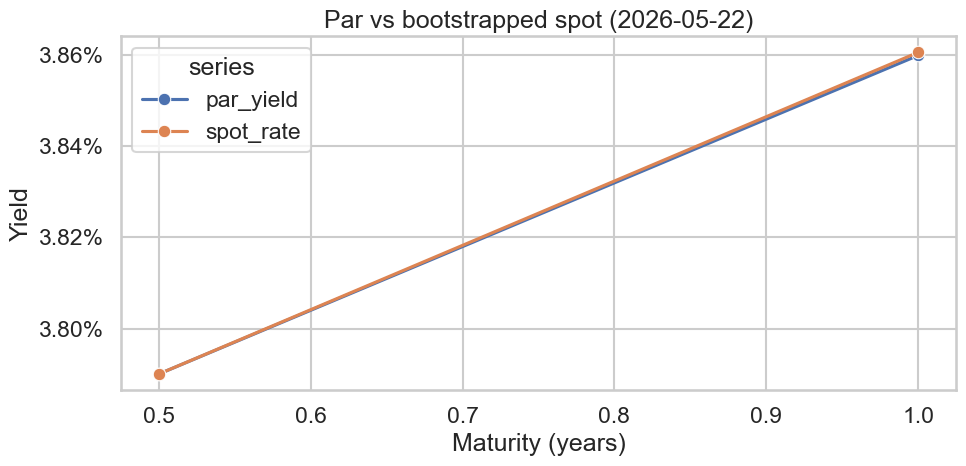

In [5]:
try:
    par_boot = par_curve_for_bootstrap(par_curve, frequency=2)
    print(
        f"Bootstrap uses {len(par_boot.points)} contiguous semiannual tenors "
        f"(of {len(par_curve.points)} par points)"
    )
    maturities, spot_rates = bootstrap_spot_curve(par_boot, frequency=2)
except ValueError as exc:
    print(f"Spot bootstrap skipped: {exc}")
    par_boot = None
    maturities, spot_rates = None, None
if par_boot is not None:
    spot_curve = USTreasurySpotCurve.from_par_curves(par_boot, frequency=2)

    df_spot = pd.DataFrame({"maturity_years": maturities, "spot_rate": spot_rates})
    df_spot["spot_rate_pct"] = 100.0 * df_spot["spot_rate"]
    display(df_spot)

    df_par_boot = curve_to_df(par_boot)
    df_cmp = df_par_boot.merge(df_spot, on="maturity_years", how="outer").sort_values("maturity_years")
    df_long = df_cmp.melt(
        id_vars="maturity_years",
        value_vars=["par_yield", "spot_rate"],
        var_name="series",
        value_name="yield",
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=df_long, x="maturity_years", y="yield", hue="series", marker="o", ax=ax)
    ax.yaxis.set_major_formatter(pct_formatter)
    ax.set_title(f"Par vs bootstrapped spot ({par_curve.as_of})")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield")
    plt.tight_layout()
    plt.show()

## 5. SOFR fixings and OIS discount bootstrap

NY Fed SOFR through 2026-05-21 (249 obs)


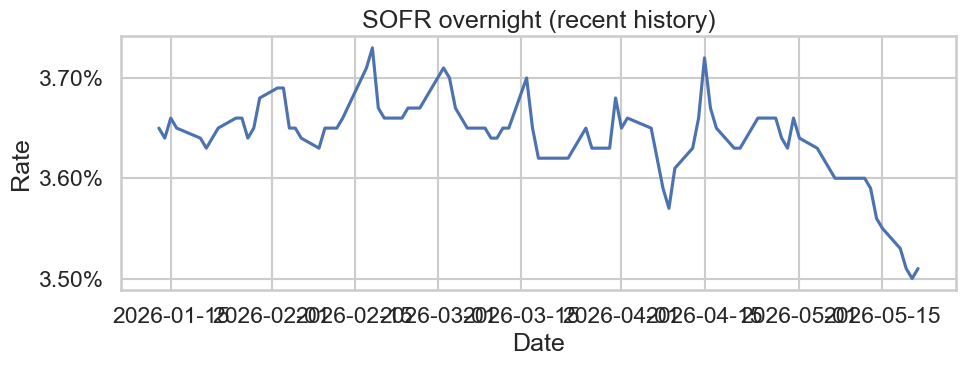

,pillar_years,discount_factor
0,0.25,0.991206
1,0.50,0.982470
2,1.00,0.965635
3,2.00,0.933554
4,5.00,0.848871


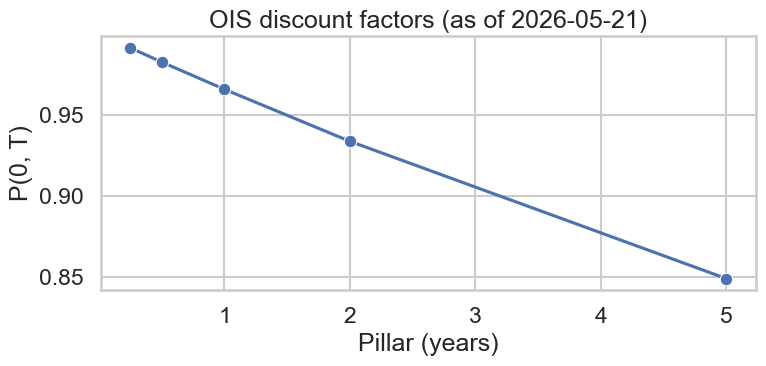

In [6]:
sofr_series = None
try:
    sofr_series = NyFedSofrSource().fetch(as_of=AS_OF)
    print(f"NY Fed SOFR through {sofr_series.as_of} ({len(sofr_series.observations)} obs)")
except Exception as exc:
    print(f"NY Fed SOFR fetch failed: {exc}")
    print("Using synthetic SOFR for offline demo.")
    obs = tuple(
        RateObservation(date=AS_OF - timedelta(days=30 - i), rate=0.035 + 0.0001 * i)
        for i in range(30)
    )
    sofr_series = RateSeries(series_id="SOFR", as_of=AS_OF, observations=obs)

df_sofr = pd.DataFrame(
    {"date": [o.date for o in sofr_series.observations], "rate": [o.rate for o in sofr_series.observations]}
)
df_sofr["rate_pct"] = 100.0 * df_sofr["rate"]
df_sofr = df_sofr.tail(90)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=df_sofr, x="date", y="rate", ax=ax)
ax.yaxis.set_major_formatter(pct_formatter)
ax.set_title("SOFR overnight (recent history)")
ax.set_xlabel("Date")
ax.set_ylabel("Rate")
plt.tight_layout()
plt.show()

ois_curve = bootstrap_ois_from_sofr(sofr_series, pillars=PILLARS)
df_ois = pd.DataFrame(
    {"pillar_years": ois_curve.pillars, "discount_factor": ois_curve.discount_factors}
)
display(df_ois)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df_ois, x="pillar_years", y="discount_factor", marker="o", ax=ax)
ax.set_title(f"OIS discount factors (as of {ois_curve.as_of})")
ax.set_xlabel("Pillar (years)")
ax.set_ylabel("P(0, T)")
plt.tight_layout()
plt.show()

## 6. Forward rate from OIS curve

In [7]:
t1, t2 = 0.25, 1.0
fwd = forward_rate_from_discount(ois_curve, t1, t2)
print(f"Forward rate from {t1}y to {t2}y: {fwd:.4%}")
print(f"Implied futures-style quote (100 - rate%): {100.0 - fwd * 100.0:.4f}")

Forward rate from 0.25y to 1.0y: 3.5307%
Implied futures-style quote (100 - rate%): 96.4693


## 7. Hull–White calibration to CME SOFR futures (SR3)

SR1 contracts: 25, SR3: 45
Calibrating on 26 SR3 contracts with future accrual


,contract,symbol,settle,volume
0,JUN 26,SR3M6,96.3175,596558
1,JUL 26,SR3N6,96.2750,418
2,AUG 26,SR3Q6,96.2300,12
3,SEP 26,SR3U6,96.1850,638182
4,DEC 26,SR3Z6,96.0500,782776
5,MAR 27,SR3H7,95.9500,554897
6,JUN 27,SR3M7,95.9400,584661
7,SEP 27,SR3U7,95.9850,451713
8,DEC 27,SR3Z7,96.0450,444961
9,MAR 28,SR3H8,96.0900,461827


Calibrated a = 0.4755, sigma = 0.0500, RMSE = 0.2249


,symbol,market_settle,model_settle,t_end_years,residual
5,SR3H7,95.9500,96.459046,0.821355,0.509046
6,SR3M7,95.9400,96.426329,1.070500,0.486329
7,SR3U7,95.9850,96.417143,1.319644,0.432143
4,SR3Z6,96.0500,96.439050,0.572211,0.389050
8,SR3Z7,96.0450,96.345108,1.568789,0.300108
3,SR3U6,96.1850,96.442312,0.323066,0.257312
11,SR3U8,96.0850,96.327566,2.335387,0.242566
2,SR3Q6,96.2300,96.448104,0.246407,0.218104
12,SR3Z8,96.0750,96.258286,2.584531,0.183286
1,SR3N6,96.2750,96.456456,0.150582,0.181456


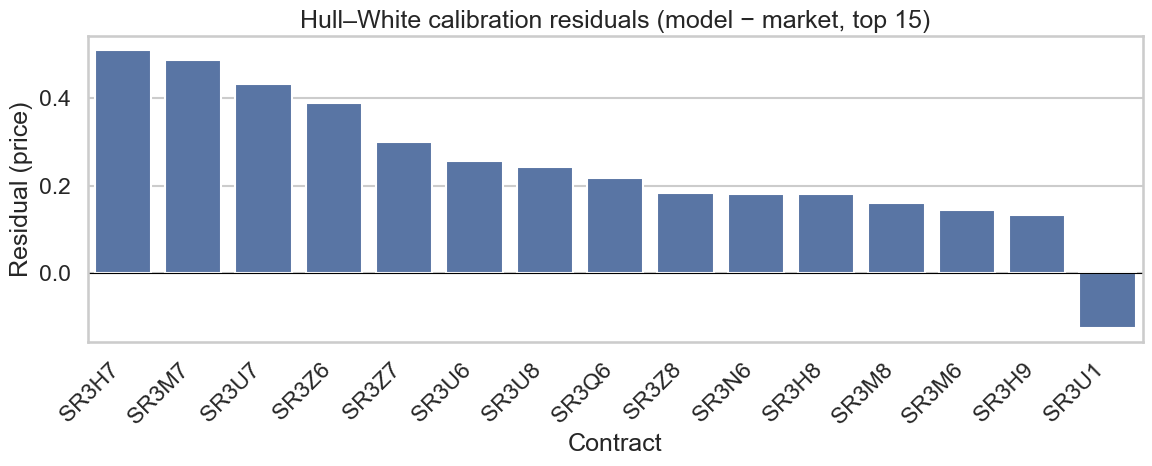

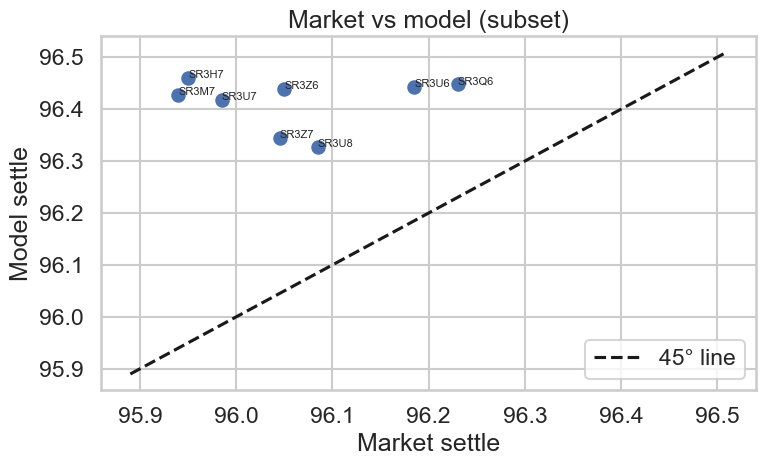

In [8]:
cme_bundle = None
try:
    cme_bundle = CmeSofrSettleBundleSource(trade_date=AS_OF).fetch(as_of=AS_OF)
    print(f"SR1 contracts: {len(cme_bundle.sr1.settles)}, SR3: {len(cme_bundle.sr3.settles)}")
except Exception as exc:
    print(f"CME settle load failed: {exc}")
    print("Place CSVs under data/raw/ (see docs/data_access.md) to run this section.")

if cme_bundle is not None:
    sr3 = sr3_curve_for_calibration(cme_bundle.sr3, ois_curve.as_of, min_volume=1)
    print(f"Calibrating on {len(sr3.settles)} SR3 contracts with future accrual")
    df_fut = pd.DataFrame(
        {
            "contract": [s.contract_month for s in sr3.settles],
            "symbol": [s.symbol for s in sr3.settles],
            "settle": [s.settle for s in sr3.settles],
            "volume": [s.volume for s in sr3.settles],
        }
    )
    display(df_fut.head(12))

    cal = None
    if sr3.settles:
        try:
            cal = HullWhite.calibrate_to_futures(sr3, ois_curve, min_volume=0)
            print(f"Calibrated a = {cal.a:.4f}, sigma = {cal.sigma:.4f}, RMSE = {cal.rmse:.4f}")
        except Exception as exc:
            print(f"Hull–White calibration failed: {exc}")

    if cal is not None:
        df_res = pd.DataFrame(
            cal.residuals, columns=["symbol", "market_settle", "model_settle", "t_end_years"]
        )
        df_res["residual"] = df_res["model_settle"] - df_res["market_settle"]
        df_res = df_res.sort_values("residual", key=abs, ascending=False).head(15)
        display(df_res)

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=df_res, x="symbol", y="residual", ax=ax)
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_title("Hull–White calibration residuals (model − market, top 15)")
        ax.set_xlabel("Contract")
        ax.set_ylabel("Residual (price)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        top = df_res.head(8)
        ax.scatter(top["market_settle"], top["model_settle"], s=80)
        lim = [
            min(top["market_settle"].min(), top["model_settle"].min()) - 0.05,
            max(top["market_settle"].max(), top["model_settle"].max()) + 0.05,
        ]
        ax.plot(lim, lim, "k--", label="45° line")
        for _, row in top.iterrows():
            ax.annotate(row["symbol"], (row["market_settle"], row["model_settle"]), fontsize=8)
        ax.set_xlabel("Market settle")
        ax.set_ylabel("Model settle")
        ax.set_title("Market vs model (subset)")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Next steps

- **Bond pricing, duration, convexity:** see [`bonds.ipynb`](bonds.ipynb).
- **Batch ingest:** `python3 scripts/ingest_market_data.py --as-of 2026-05-22`.
- **Interactive dashboard:** `fixed_income.viz.create_dash_app()` (Plotly/Dash).